\**Catatan**

Dataset hanya terdiri dari **nama anak, tanggal lahir, berat badan, dan tinggi badan**,

**Suggestion tambah data:**  
* Jenis kelamin,
* Riwayat ISPA
* Riwayat Diare
* Berat & Panjang lahir,
* ASI eksklusif (Ya/Tidak),
* MP-ASI (Ya/Tidak)
* Imunisasi (Ya/Tidak)
* Ketersediaan air bersih termasuk konsumsi air minum
* Tingkat pendidikan Ibu
* Pemeriksaan ANC
* Status ekonomi
* Tinggi badan Ibu

**Sumber**
1. Factors Associated With Child Stunting, Wasting, and Underweight
in 35 Low- and Middle-Income Countries (https://pubmed.ncbi.nlm.nih.gov/32320037/)
2. Improved sanitation is associated with reduced child stuntingamongst Indonesian children under 3 years of age (https://onlinelibrary.wiley.com/doi/epdf/10.1111/mcn.12741)
3. Effect of parental formal education on risk of child stunting in Indonesia and Bangladesh: a cross-sectional study (https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(08)60169-5/abstract)
4. A review of child stunting determinants in Indonesia (https://onlinelibrary.wiley.com/doi/epdf/10.1111/mcn.12617)
5. Permenkes Nomor 2 Tahun 2020 tentang Standar Antropometri Anak (https://peraturan.bpk.go.id/Details/152505/permenkes-no-2-tahun-2020)

**DATASET**

Project ini menggunakan **dummy dataset** untuk sementara waktu sampai dengan **real dataset** disediakan oleh yayasan

# **Checkpoint 1 & 2 - Data Preparation**

* **Data Cleaning** : Membersihkan missing value, duplikasi, kesalahan input, konversi tipe data, dan validasi nilai berat serta tinggi badan
* **Feature Engineering** : Menghitung umur (bulan), imt, Height-for-Age Z-score (HAZ), kelompok umur, dan status stunting
* **Data Transformation** : Normalisasi atau standarisasi data (jika diperlukan), encoding variabel kategorik
* **Validasi Dataset** : Memastikan seluruh fitur telah dihitung dengan benar dan siap digunakan

**Indikator :**
* HAZ (TB/U)
* WAZ (BB/U)
* WHZ (BB/TB)
* BAZ (IMT/U)

**Create dummy dataset**


In [2]:
# Mounting Folder Kerja
print(f"Mounting folder kerja")

import os
dir = os.getcwd()
os.chdir(dir)
print(dir)
print(f"Mounting berhasil !")

Mounting folder kerja
c:\Users\ACER\Downloads\#Bootcamp DS\stuntingrisk\stuntingRisk
Mounting berhasil !


In [3]:
# Load library
# !pip install skimpy tableone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
print(f"Import library berhasil !")

Import library berhasil !


# **Checkpoint 2,3,4 - Exploratory Data Analysis (EDA)**

* **Analisis Univariat** : Menghitung statistik deskriptif (mean, median, SD, minimum, maksimum, IQR) untuk setiap variabel
* **Analisis Bivariat** : Mengeksplorasi hubungan umur, berat, tinggi, imt, dan status stunting
* **Visualisasi Data** : Membuat histogram, boxplot, scatter plot, density plot, dan correlation matrix
* **Penyusunan Insight** : Menginterpretasikan pola, tren & karakteristik data


## **Deskripsi Dataset**

In [4]:
df_dummy = pd.read_csv("dummy_dataset_stunting.csv")
df_dummy.columns = df_dummy.columns.str.lower()

ref_who = pd.read_csv("who_length_height_for_age_reference_0_60_months.xlsx - WHO_reference.csv")
ref_who.columns = ref_who.columns.str.lower()

print(
    """
    Dataset ini merupakan dataset dummy/sintetis yang dibuat untuk keperluan pembelajaran dan pengembangan model Machine Learning dalam analisis risiko stunting pada anak.
    Dataset merepresentasikan data karakteristik anak, pengukuran antropometri, riwayat kesehatan, status imunisasi, serta informasi kesehatan maternal yang berkaitan dengan
    kondisi pertumbuhan anak.

    Setiap baris pada dataset merepresentasikan satu anak, sedangkan setiap kolom merepresentasikan karakteristik atau indikator kesehatan yang diamati.
    Variabel antropometri meliputi usia anak dalam bulan, berat badan, tinggi badan, dan BMI. Dataset juga mencakup beberapa variabel riwayat kesehatan
    seperti Acute Respiratory Infection (ARI), kelengkapan imunisasi, serta jumlah kunjungan Antenatal Care (ANC) selama masa kehamilan.

    Variabel status_stunting digunakan sebagai variabel target yang menggambarkan kategori status pertumbuhan anak, misalnya Normal, Stunted, Severely Stunted, dan Tall.
    Karena dataset ini bersifat dummy/sintetis, data tidak merepresentasikan individu atau kondisi kesehatan nyata dan tidak dapat digunakan untuk diagnosis klinis maupun
    pengambilan keputusan medis.

    Dataset ditujukan untuk simulasi proses Exploratory Data Analysis (EDA), statistical analysis, feature selection, classification modelling, model evaluation
    dan interpretasi risiko stunting
    """
)

print(f"Import data berhasil !")


    Dataset ini merupakan dataset dummy/sintetis yang dibuat untuk keperluan pembelajaran dan pengembangan model Machine Learning dalam analisis risiko stunting pada anak.
    Dataset merepresentasikan data karakteristik anak, pengukuran antropometri, riwayat kesehatan, status imunisasi, serta informasi kesehatan maternal yang berkaitan dengan
    kondisi pertumbuhan anak.

    Setiap baris pada dataset merepresentasikan satu anak, sedangkan setiap kolom merepresentasikan karakteristik atau indikator kesehatan yang diamati.
    Variabel antropometri meliputi usia anak dalam bulan, berat badan, tinggi badan, dan BMI. Dataset juga mencakup beberapa variabel riwayat kesehatan
    seperti Acute Respiratory Infection (ARI), kelengkapan imunisasi, serta jumlah kunjungan Antenatal Care (ANC) selama masa kehamilan.

    Variabel status_stunting digunakan sebagai variabel target yang menggambarkan kategori status pertumbuhan anak, misalnya Normal, Stunted, Severely Stunted, dan Tall.
    Karen

## **Preparation**

In [5]:
def calculate_haz(sex,age,height):
  z = height
  ref = ref_who.loc[(ref_who["age_months"] == age) & (ref_who["sex"] == sex)].iloc[0]
  l_val = ref["l"]
  m_val = ref["m"]
  s_val = ref["s"]
  haz = (((z/m_val)**l_val)-1)/(l_val*s_val)
  return haz.round(2)

def classify_stunting(haz):
  if haz < -3:
    return "Severely stunted"
  elif haz < -2:
    return "Stunted"
  elif haz <= 3:
    return "Normal"
  else:
    return "Tall"

print(f"Membuat function hitung & klasifikasi HAZ berhasil !")

Membuat function hitung & klasifikasi HAZ berhasil !


In [6]:
# Ubah variabel ke tipe kategorikal
df_dummy['anc_visits'] = df_dummy['anc_visits'].astype("category")
df_dummy['maternal_education'] = df_dummy['maternal_education'].astype("category")
df_dummy['maternal_marriage_age'] = df_dummy['maternal_marriage_age'].astype("category")
df_dummy['drinking_water_source'] = df_dummy['drinking_water_source'].astype("category")
df_dummy['clean_water_availability'] = df_dummy['clean_water_availability'].astype("category")
df_dummy['iodized_salt'] = df_dummy['iodized_salt'].astype("category")
df_dummy['complete_immunization'] = df_dummy['complete_immunization'].astype("category")
df_dummy['complementary_feeding'] = df_dummy['complementary_feeding'].astype("category")
df_dummy['exclusive_breastfeeding'] = df_dummy['exclusive_breastfeeding'].astype("category")
df_dummy['vitamin_a_consumption'] = df_dummy['vitamin_a_consumption'].astype("category")
df_dummy['skilled_birth_attendant'] = df_dummy['skilled_birth_attendant'].astype("category")
df_dummy['history_diarrhea'] = df_dummy['history_diarrhea'].astype("category")
df_dummy['history_ari'] = df_dummy['history_ari'].astype("category")
df_dummy['sex'] = df_dummy['sex'].astype("category")
df_dummy['wealth_index'] = df_dummy['wealth_index'].astype("category")
df_dummy['sanitation_facility'] = df_dummy['sanitation_facility'].astype("category")

# df_dummy.select_dtypes(exclude="number").iloc[:,1:18].columns
# df_dummy.select_dtypes(include="number").columns
numerical_columns = ['birth_weight_g', 'birth_length_cm', 'measurement_weight_g',
       'measurement_height_cm', 'measurement_bmi', 'measurement_age_months',
       'maternal_height_cm', 'haz_score']
categorical_columns = ['sex','cat_age','history_ari', 'history_diarrhea', 'skilled_birth_attendant',
       'vitamin_a_consumption', 'exclusive_breastfeeding',
       'complementary_feeding', 'complete_immunization', 'iodized_salt',
       'clean_water_availability', 'drinking_water_source',
       'maternal_marriage_age', 'maternal_education', 'anc_visits',
       'wealth_index', 'sanitation_facility']
columns = numerical_columns + categorical_columns

print(f"Convert variabel berhasil !")

Convert variabel berhasil !


In [7]:
# Menentukan status stunting berdasarkan nilai HAZ WHO
df_dummy = (
  df_dummy
  .assign(
    haz_score = lambda x: x.apply(
      lambda y: calculate_haz(
          y["sex"],
          y["measurement_age_months"],
          y["measurement_height_cm"]
      ), axis=1
    ),
    stunting_status = lambda x: x["haz_score"].apply(classify_stunting),
    cat_age = lambda x: pd.cut(
        x["measurement_age_months"],
        bins=[0, 25, 61, float("inf")],
        labels=["0-24", "25-60", ">60"],
        right=False
    ).astype("category")
  )
)

# Simpan data yang sudah dibersihkan
print("Data bersih tersimpan!")

Data bersih tersimpan!


In [8]:
# Deskripsi Dataset
print("="*50)
print("DUMMY DATASET")
print("="*50)
print(f"Total data: {len(df_dummy)} anak")
print(f"Jumlah missing :\n{df_dummy.isna().sum()}")
print("="*50)
df_dummy[numerical_columns].describe().round(2).T

DUMMY DATASET
Total data: 121999 anak
Jumlah missing :
child_id                    0
birth_weight_g              0
birth_length_cm             0
measurement_weight_g        0
measurement_height_cm       0
measurement_bmi             0
measurement_age_months      0
sex                         0
history_ari                 0
history_diarrhea            0
skilled_birth_attendant     0
vitamin_a_consumption       0
exclusive_breastfeeding     0
complementary_feeding       0
complete_immunization       0
iodized_salt                0
clean_water_availability    0
drinking_water_source       0
maternal_height_cm          0
maternal_marriage_age       0
maternal_education          0
anc_visits                  0
wealth_index                0
sanitation_facility         0
haz_score                   0
stunting_status             0
cat_age                     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
birth_weight_g,121999.0,3077.85,817.83,1657.00,2374.98,3077.66,3782.02,4500.00
birth_length_cm,121999.0,49.44,3.53,43.30,46.38,49.44,52.47,55.60
measurement_weight_g,121999.0,10148.28,4587.57,2200.00,6165.04,10164.41,14114.72,18120.00
measurement_height_cm,121999.0,88.66,17.30,40.01,77.00,89.80,101.20,128.00
measurement_bmi,121999.0,14.81,10.68,1.42,7.58,12.51,18.71,108.82
measurement_age_months,121999.0,30.17,17.57,0.00,15.00,30.00,45.00,60.00
maternal_height_cm,121999.0,152.47,10.07,135.00,143.80,152.46,161.16,170.00
haz_score,121999.0,0.01,2.72,-7.04,-2.22,0.00,2.20,8.79


## **Time Series**


In [9]:
import numpy as np

np.random.seed(42)

N_BULAN = 5
n_anak = len(df_dummy) // N_BULAN

df_anak_unik = df_dummy.iloc[:n_anak].reset_index(drop=True)

kolom_tetap = [
    "child_id", "birth_weight_g", "birth_length_cm", "sex",
    "history_ari", "history_diarrhea", "skilled_birth_attendant",
    "vitamin_a_consumption", "exclusive_breastfeeding", "complementary_feeding",
    "complete_immunization", "iodized_salt", "clean_water_availability",
    "drinking_water_source", "maternal_height_cm", "maternal_marriage_age",
    "maternal_education", "anc_visits", "wealth_index", "sanitation_facility",
    "cat_age"
]
kolom_tetap = [k for k in kolom_tetap if k in df_anak_unik.columns]

def calculate_haz(sex, age, height):
    z = height
    age = int(round(age))
    match = ref_who.loc[(ref_who["age_months"] == age) & (ref_who["sex"] == sex)]
    if match.empty:
        return np.nan
    ref = match.iloc[0]
    l_val, m_val, s_val = ref["l"], ref["m"], ref["s"]
    haz = (((z / m_val) ** l_val) - 1) / (l_val * s_val)
    return round(haz, 2)

def classify_stunting(haz):
    if pd.isna(haz):
        return "Unknown"
    if haz < -3:
        return "Severely stunted"
    elif haz < -2:
        return "Stunted"
    elif haz <= 3:
        return "Normal"
    else:
        return "Tall"

# --- BARU: laju pertumbuhan disesuaikan umur (bukan flat) ---
def get_laju_pertumbuhan(umur_bulan):
    if umur_bulan < 6:
        mean_tinggi, mean_berat = 2.0, 0.6
    elif umur_bulan < 12:
        mean_tinggi, mean_berat = 1.2, 0.4
    elif umur_bulan < 24:
        mean_tinggi, mean_berat = 0.9, 0.25
    elif umur_bulan < 36:
        mean_tinggi, mean_berat = 0.7, 0.2
    else:
        mean_tinggi, mean_berat = 0.5, 0.15
    laju_tinggi = np.random.normal(loc=mean_tinggi, scale=mean_tinggi * 0.3)
    laju_berat  = np.random.normal(loc=mean_berat, scale=mean_berat * 0.3)
    return laju_tinggi, laju_berat

umur_maks = ref_who["age_months"].max()

records = []
for _, row in df_anak_unik.iterrows():
    umur_awal   = row["measurement_age_months"]
    tinggi_awal = row["measurement_height_cm"]
    berat_awal  = row["measurement_weight_g"] / 1000
    sex         = row["sex"]

    for bulan in range(1, N_BULAN + 1):
        umur = umur_awal + (bulan - 1)
        if umur > umur_maks:
            continue

        # --- BARU: pakai laju sesuai umur, bukan angka flat ---
        laju_tinggi, laju_berat = get_laju_pertumbuhan(umur_awal)

        tinggi = tinggi_awal + laju_tinggi * (bulan - 1)
        berat_kg = berat_awal + laju_berat * (bulan - 1)

        rec = {k: row[k] for k in kolom_tetap}
        rec.update({
            "bulan_ke": bulan,
            "measurement_age_months": umur,
            "measurement_height_cm": round(tinggi, 1),
            "measurement_weight_g": round(berat_kg * 1000, 0),
            "measurement_bmi": round(berat_kg / ((tinggi / 100) ** 2), 2),
        })
        records.append(rec)

df_timeseries = pd.DataFrame(records)

df_timeseries["haz_score"] = df_timeseries.apply(
    lambda r: calculate_haz(r["sex"], r["measurement_age_months"], r["measurement_height_cm"]),
    axis=1
)
df_timeseries["stunting_status"] = df_timeseries["haz_score"].apply(classify_stunting)

print(f"Total baris time series: {len(df_timeseries)}")
print(f"Total anak unik: {df_timeseries['child_id'].nunique()}")
print(f"Baris yang dilewati (umur > {umur_maks} bulan): {n_anak * N_BULAN - len(df_timeseries)}")
df_timeseries.to_csv("dummy_dataset_ts.csv", index=False)

Total baris time series: 121902
Total anak unik: 24399
Baris yang dilewati (umur > 60 bulan): 93


In [10]:
df_timeseries.head()

,child_id,birth_weight_g,birth_length_cm,sex,history_ari,history_diarrhea,skilled_birth_attendant,vitamin_a_consumption,exclusive_breastfeeding,complementary_feeding,...,wealth_index,sanitation_facility,cat_age,bulan_ke,measurement_age_months,measurement_height_cm,measurement_weight_g,measurement_bmi,haz_score,stunting_status
0,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,1,5,66.2,5390.0,12.30,0.98,Normal
1,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,2,6,68.6,6264.0,13.32,1.27,Normal
2,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,3,7,69.9,6506.0,13.31,1.13,Normal
3,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,4,8,75.0,7604.0,13.50,2.64,Normal
4,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,5,9,73.1,8181.0,15.32,1.22,Normal


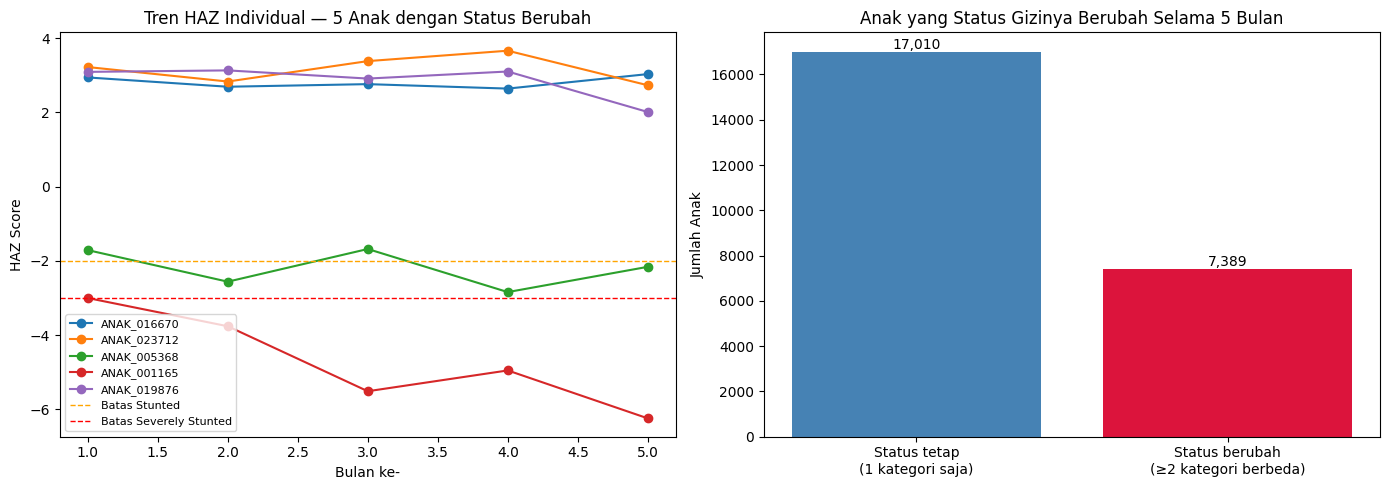

Total anak: 24399
Anak dengan status BERUBAH selama 5 bulan: 7389 (30.3%)
Anak dengan status TETAP selama 5 bulan: 17010 (69.7%)


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. Tren HAZ individual — beberapa anak dengan status BERUBAH antar bulan
# ==========================================
pivot_status = df_timeseries.pivot(index="child_id", columns="bulan_ke", values="stunting_status")
urutan_sev = {"Tall": 0, "Normal": 1, "Stunted": 2, "Severely stunted": 3, "Unknown": np.nan}
sev_numeric = pivot_status.replace(urutan_sev)

# cari anak yang status-nya BERUBAH kategori setidaknya sekali (nilai unik per baris > 1)
anak_berubah = sev_numeric[sev_numeric.nunique(axis=1) > 1].index

sample_berubah = np.random.RandomState(1).choice(anak_berubah, size=5, replace=False)

for cid in sample_berubah:
    data_anak = df_timeseries[df_timeseries["child_id"] == cid].sort_values("bulan_ke")
    axes[0].plot(data_anak["bulan_ke"], data_anak["haz_score"], marker="o", label=cid)

axes[0].axhline(-2, color="orange", linestyle="--", linewidth=1, label="Batas Stunted")
axes[0].axhline(-3, color="red", linestyle="--", linewidth=1, label="Batas Severely Stunted")
axes[0].set_xlabel("Bulan ke-")
axes[0].set_ylabel("HAZ Score")
axes[0].set_title("Tren HAZ Individual — 5 Anak dengan Status Berubah")
axes[0].legend(fontsize=8)

# ==========================================
# 2. Perbandingan: apa yang terlihat di cross-section (1 titik) vs time series (5 titik)
# ==========================================
jumlah_berubah = len(anak_berubah)
jumlah_tetap = df_timeseries["child_id"].nunique() - jumlah_berubah

axes[1].bar(
    ["Status tetap\n(1 kategori saja)", "Status berubah\n(≥2 kategori berbeda)"],
    [jumlah_tetap, jumlah_berubah],
    color=["steelblue", "crimson"]
)
axes[1].set_ylabel("Jumlah Anak")
axes[1].set_title("Anak yang Status Gizinya Berubah Selama 5 Bulan")
for i, v in enumerate([jumlah_tetap, jumlah_berubah]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("alasan_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total anak: {df_timeseries['child_id'].nunique()}")
print(f"Anak dengan status BERUBAH selama 5 bulan: {jumlah_berubah} ({jumlah_berubah/df_timeseries['child_id'].nunique()*100:.1f}%)")
print(f"Anak dengan status TETAP selama 5 bulan: {jumlah_tetap} ({jumlah_tetap/df_timeseries['child_id'].nunique()*100:.1f}%)")

Severely Stunted — jauh lebih pendek dari standar (paling parah, kekurangan gizi kronis)
Stunted — lebih pendek dari standar (stunting, tapi lebih ringan)
Normal — tinggi badannya wajar/sesuai standar
Tall — jauh lebih tinggi dari standar

In [11]:
# Now import TableOne
# !pip install tableone

from tableone import TableOne

# Ringkasan tabel stunting
mytable = TableOne(
    data = df_timeseries,
    columns = columns,
    categorical = categorical_columns,
    continuous = numerical_columns,
    groupby="stunting_status",
    pval=True
)

print(f"Tabel Ringkasan Data Stunting")
print("="*150)
print(mytable.tabulate(tablefmt="github"))
print("="*150)
print(f"Simpan tabel dalam bentuk html")
mytable.to_html("table_summary.html")
print(f"Tabel berhasil disimpan!")

ModuleNotFoundError: No module named 'tableone'

## **Visualisasi Dataset**

Gambaran Distribusi Status Stunting


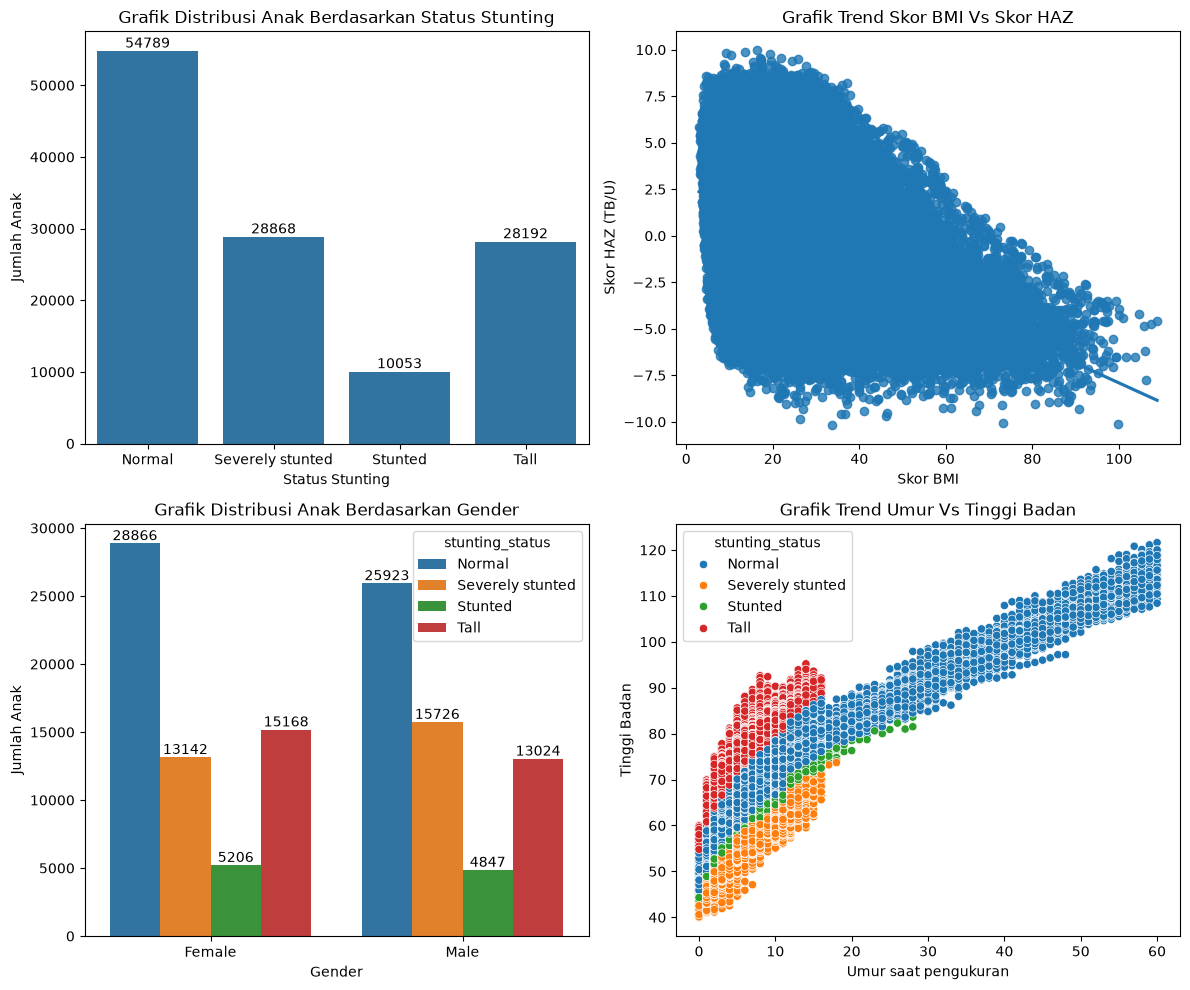

In [ ]:
print(f"Gambaran Distribusi Status Stunting")
print("="*130)
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
ax = sns.countplot(df_timeseries, x='stunting_status')
ax.set_ylabel("Jumlah Anak")
ax.set_xlabel("Status Stunting")
ax.bar_label(ax.containers[0])
ax.title.set_text('Grafik Distribusi Anak Berdasarkan Status Stunting')

plt.subplot(2, 2, 2)
ax1 = sns.regplot(df_timeseries, x='measurement_bmi', y='haz_score')
plt.title('Body mass index vs HAZ Score')
ax1.set_xlabel("Skor BMI")
ax1.set_ylabel("Skor HAZ (TB/U)")
ax1.title.set_text('Grafik Trend Skor BMI Vs Skor HAZ')

plt.subplot(2, 2, 3)
ax2 = sns.countplot(df_timeseries, x='sex', hue='stunting_status')
ax2.set_ylabel("Jumlah Anak")
ax2.set_xlabel("Gender")
for x in ax2.containers :
  ax2.bar_label(x)
ax2.title.set_text('Grafik Distribusi Anak Berdasarkan Gender')

plt.subplot(2, 2, 4)
ax3 = sns.scatterplot(df_timeseries, x="measurement_age_months", y="measurement_height_cm", hue="stunting_status")
ax3.set_xlabel("Umur saat pengukuran")
ax3.set_ylabel("Tinggi Badan")
ax3.title.set_text("Grafik Trend Umur Vs Tinggi Badan")

plt.tight_layout()
plt.savefig("grafik_kombinasi.png", dpi=300, bbox_inches='tight')
plt.show()

Tabel Korelasi Data Stunting


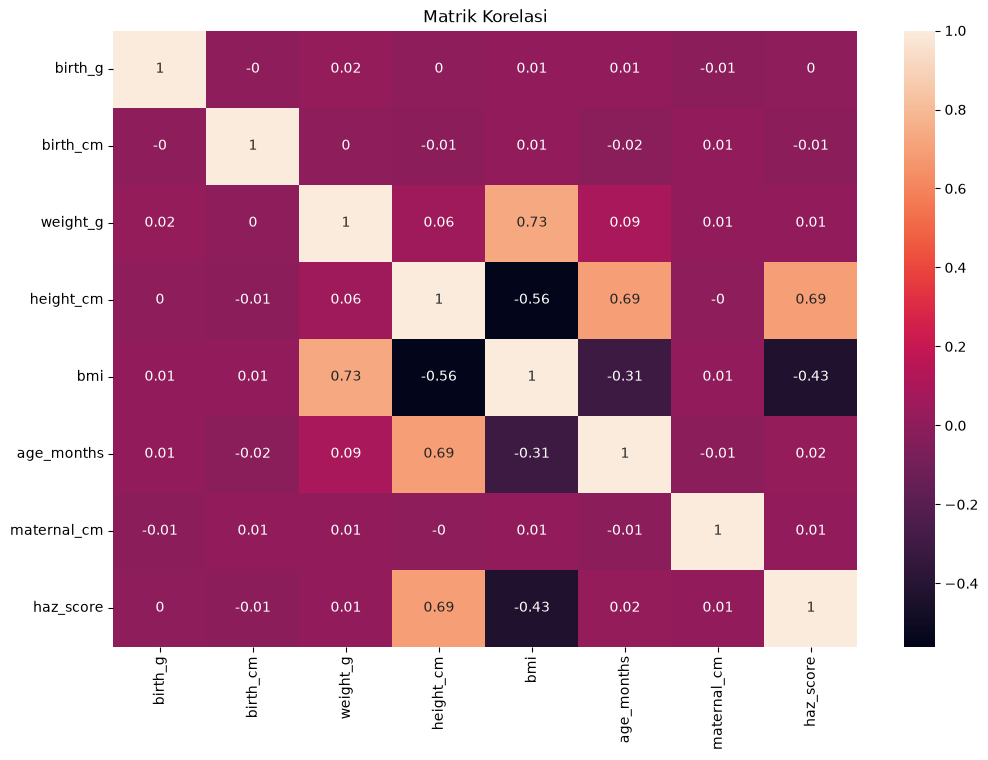

Variabel dengan nilai koefisien r > 0.5
** bmi vs height_cm : 0.64
** bmi vs age_months : 0.53
** bmi vs weight_g : 0.62
** age_months vs height_cm : 0.84


In [ ]:
# Matriks Korelasi
corr_tab = (
    df_timeseries.loc[:,["birth_weight_g","birth_length_cm","measurement_weight_g","measurement_height_cm","measurement_bmi","measurement_age_months","maternal_height_cm","haz_score"]]
    .rename(
        columns = {
          "birth_weight_g":"birth_g","birth_length_cm":"birth_cm",
          "measurement_weight_g":"weight_g","measurement_height_cm":"height_cm",
          "measurement_bmi":"bmi","measurement_age_months":"age_months","maternal_height_cm":"maternal_cm"
        }
      ).corr().round(2)
)

print(f"Tabel Korelasi Data Stunting")
print("="*50)
# print(corr_tab)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_tab,annot=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Matrik Korelasi')
plt.savefig('matrik_korelasi', dpi=300, bbox_inches='tight')
plt.show()
print("="*50)
print(f"Variabel dengan nilai koefisien r > 0.5")
print(f"** bmi vs height_cm : 0.64")
print(f"** bmi vs age_months : 0.53")
print(f"** bmi vs weight_g : 0.62")
print(f"** age_months vs height_cm : 0.84")

**Insight :**

1. Prevalensi stunting cukup besar. Sekitar 27,44% anak termasuk kategori Stunted atau Severely stunted.
2. Dataset memiliki ketidakseimbangan kelas.
| Gender | Normal | Severe | Stunted |  Tall |
| ------ | -----: | -----: | ------: | ----: |
| Female |  56,8% |  15,5% |   11,2% | 16,6% |
| Male   |  56,0% |  17,3% |   10,9% | 15,6% |

3. Terlihat adanya tren negatif : Semakin tinggi skor BMI, skor HAZ cenderung menurun.Secara visual, garis regresinya juga menunjukkan kemiringan negatif. Nampak aneh, tetapi karena HAZ dan BMI tidak berdiri sendiri (merupakan hasil perhitungan dari data lain baca : tinggi badan, berat badan). Karena itu, hubungan negatif antara BMI-for-age dan HAZ belum tentu menunjukkan hubungan biologis sederhana bahwa BMI tinggi menyebabkan stunting.

Variabel siginifikan (P Value) terhadap Status Stunting
* measurement_height_cm : 0.001
* measurement_bmi : 0.001
* measurement_age_months : 0.001
* cat_age  : 0.001
* history_ari : 0.035
* complete_immunization : 0.021
* anc_visits : 0.032

Variabel dengan nilai koefisien r > 0.5
* bmi vs height_cm : 0.64
* bmi vs age_months : 0.53
* bmi vs weight_g : 0.62
* age_months vs height_cm : 0.84

4. *Point 3* diperjelas dengan nilai koef.r pada **age_months vs height_cm : 0.84**. Variabel yang signifikan terhadap stunting sebagian besar berasal dari kelompok antropometri yang juga saling berkorelasi

# **Checkpoint 5 & 6  - Machine Learning**

* **Pengembangan Model** : Melatih berbagai macam model yang memungkinkan (Logistic Regression, Decision Tree, dan Random Forest)
* **Evaluasi Model** : Menghitung Accuracy, Precision, Recall, F1-score, ROC-AUC, serta Confusion Matrix	Hasil
* **Interpretasi Model** : Membandingkan performa mode
* **Pelaporan** : Menyusun laporan akhir, slide presentasi serta rekomendasi implementasi model


In [15]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## **Time-Series Feature Engineering & Temporal Splitting**

Untuk membuat model yang memahami *perkembangan* anak, kita akan membuat fitur 'Lag' (nilai dari bulan sebelumnya). Ini mengubah masalah dari klasifikasi statis menjadi prediksi berbasis tren.

In [16]:
# Split data
import re

# 1. Pastikan data terurut berdasarkan anak dan bulan
df_ts_sorted = df_timeseries.sort_values(by=['child_id', 'bulan_ke'])

# 2. Membuat Fitur Lag (Kondisi Bulan Sebelumnya)
# Kita ingin model tahu berat, tinggi, dan BMI bulan lalu untuk memprediksi status bulan ini
df_ts_sorted['weight_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_weight_g'].shift(1)
df_ts_sorted['height_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_height_cm'].shift(1)
df_ts_sorted['bmi_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_bmi'].shift(1)
df_ts_sorted['stunting_lag_1'] = df_ts_sorted.groupby('child_id')['stunting_status'].shift(1)

# Hapus baris bulan ke-1 karena tidak punya data bulan ke-0 (NaN)
df_final_ts = df_ts_sorted.dropna(subset=['weight_lag_1']).reset_index(drop=True)

# 3. Encoding Kategorikal
# Pilih fitur yang relevan untuk time-series
features_ts = [
    'measurement_age_months', 'sex', 'history_ari', 'history_diarrhea',
    'complete_immunization', 'weight_lag_1', 'height_lag_1', 'bmi_lag_1',
    'stunting_lag_1', 'wealth_index', 'maternal_education'
]

X_ts = df_final_ts[features_ts]
y_ts = df_final_ts['stunting_status']

# One-Hot Encoding untuk fitur kategorikal
X_ts_encoded = pd.get_dummies(X_ts, drop_first=True)

# Label Encoding untuk target
le_ts = LabelEncoder()
y_ts_encoded = le_ts.fit_transform(y_ts)

# 4. Temporal Split (Data bulan terakhir untuk Testing)
# Dalam time-series industri, kita tidak mengacak, tapi memisahkan berdasarkan waktu
train_idx = df_final_ts[df_final_ts['bulan_ke'] < 5].index
test_idx = df_final_ts[df_final_ts['bulan_ke'] == 5].index

X_train_ts, X_test_ts = X_ts_encoded.iloc[train_idx], X_ts_encoded.iloc[test_idx]
y_train_ts, y_test_ts = y_ts_encoded[train_idx], y_ts_encoded[test_idx]

# Membersihkan nama kolom untuk XGBoost agar tidak ada karakter spesial
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_ts.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_train_ts.columns]
X_test_ts.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_test_ts.columns]

print(f"Alur Time-Series Siap!")
print(f"Jumlah Baris Training: {len(X_train_ts)}")
print(f"Jumlah Baris Testing (Bulan ke-5): {len(X_test_ts)}")

Alur Time-Series Siap!
Jumlah Baris Training: 73154
Jumlah Baris Testing (Bulan ke-5): 24349


## **Modelling**

In [17]:
# Setup model
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    "XGBoost" : XGBClassifier(
        n_estimators=100, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42) ,
    "AdaBoost" : AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=200,
        learning_rate=0.1,
        random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5)
}

def get_best_model(models,X_train_ts,y_train_ts,X_test_ts,y_test_ts):
    results = []
    total_models = len(models)
    print(f"Training ...")
    for i, (name, model) in enumerate(models.items(), start=1):
        print(f"="*50)
        print(f"Training model {i}/{total_models} : {name}...")
        model.fit(X_train_ts,y_train_ts)
        y_pred_ts = model.predict(X_test_ts)

        # confusion matrix
        cm = confusion_matrix(y_test_ts,y_pred_ts)
        cr = classification_report(y_test_ts,y_pred_ts)

        print(f"Confusion Matrix Model {name}")
        print(cm)
        print(f"Classification Report {name}")
        print(cm)
        
        acc = accuracy_score(y_test_ts, y_pred_ts)
        f1_macro = f1_score(y_test_ts, y_pred_ts, average='macro')
        f1_weighted = f1_score(y_test_ts, y_pred_ts, average='weighted')
        if hasattr(model, "predict_proba"):
            y_prob_ts = model.predict_proba(X_test_ts)
            auc_score = roc_auc_score(y_test_ts,y_prob_ts,multi_class="ovo",average="macro")
        else:
            auc_score = np.nan

        print(f"Akurasi {round(acc, 4)}")
        print(f"F1 Score Macro {round(f1_macro, 4)}")
        print(f"Weighted F1 {round(f1_weighted, 4)}")
        print(f"Model {name} selesai di Training ...")

        results.append({
            'Model': name,
            'Accuracy': round(acc, 4),
            'Macro F1': round(f1_macro, 4),
            'Weighted F1': round(f1_weighted, 4),
            'ROC-AUC': round(auc_score, 4)
        })
    print(f"Training selesai ...")
    return results

res = get_best_model(models,X_train_ts,y_train_ts,X_test_ts,y_test_ts)

Training ...
Training model 1/3 : XGBoost...
Confusion Matrix Model XGBoost
[[9466  249  689  728]
 [ 182 4945  577    0]
 [ 642  709  789    0]
 [ 800    0    0 4573]]
Classification Report XGBoost
[[9466  249  689  728]
 [ 182 4945  577    0]
 [ 642  709  789    0]
 [ 800    0    0 4573]]
Akurasi 0.8121
F1 Score Macro 0.7343
Weighted F1 0.8112
Model XGBoost selesai di Training ...
Training model 2/3 : AdaBoost...
Confusion Matrix Model AdaBoost
[[9473  249  688  722]
 [ 182 4932  590    0]
 [ 646  706  788    0]
 [ 805    0    0 4568]]
Classification Report AdaBoost
[[9473  249  688  722]
 [ 182 4932  590    0]
 [ 646  706  788    0]
 [ 805    0    0 4568]]
Akurasi 0.8116
F1 Score Macro 0.7336
Weighted F1 0.8109
Model AdaBoost selesai di Training ...
Training model 3/3 : KNN...
Confusion Matrix Model KNN
[[8971  421  133 1607]
 [1675 3750  241   38]
 [1387  623  103   27]
 [1322    2    1 4048]]
Classification Report KNN
[[8971  421  133 1607]
 [1675 3750  241   38]
 [1387  623  103 

In [18]:
# Hasil perbandingan model
results_df = pd.DataFrame(res)
results_df

,Model,Accuracy,Macro F1,Weighted F1,ROC-AUC
0,XGBoost,0.8121,0.7343,0.8112,0.9263
1,AdaBoost,0.8116,0.7336,0.8109,0.9238
2,KNN,0.6929,0.5639,0.6703,0.8167


--- HASIL PEMODELAN TIME-SERIES (PREDIKSI BULAN KE-5) ---
Classificaiton Report
              precision    recall  f1-score   support

           0       0.85      0.85      0.85     11132
           1       0.84      0.87      0.85      5704
           2       0.38      0.37      0.38      2140
           3       0.86      0.85      0.86      5373

    accuracy                           0.81     24349
   macro avg       0.73      0.73      0.73     24349
weighted avg       0.81      0.81      0.81     24349

Confusion Matrix
[[9466  249  689  728]
 [ 182 4945  577    0]
 [ 642  709  789    0]
 [ 800    0    0 4573]]


10 Fitur Paling Berpengaruh dalam Pertumbuhan Anak
stunting_lag_1_Tall                42.481750
stunting_lag_1_Severely stunted    42.281673
stunting_lag_1_Stunted             13.574738
height_lag_1                        0.680981
measurement_age_months              0.346524
sex_Male                            0.154180
wealth_index_Richest                0.056489
history

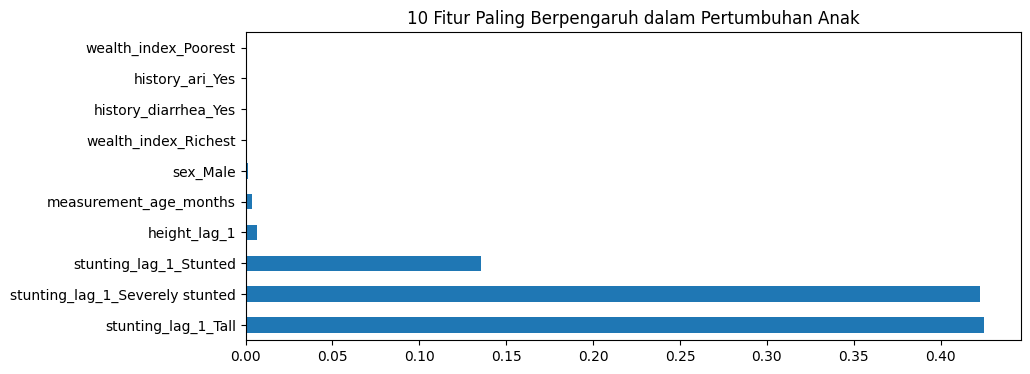

In [19]:
# Best model = XGBoost
xgb = models["XGBoost"]
xgb.fit(X_train_ts, y_train_ts)
y_pred_ts = xgb.predict(X_test_ts)

# Confusion matrix & classificaiton report
cm = confusion_matrix(y_test_ts,y_pred_ts)
cr = classification_report(y_test_ts,y_pred_ts)

# Features importance
feat_importances = pd.Series(xgb.feature_importances_, index=X_train_ts.columns)


print("--- HASIL PEMODELAN TIME-SERIES (PREDIKSI BULAN KE-5) ---")
print(f"Classificaiton Report")
print(cr)
print(f"Confusion Matrix")
print(cm)
print("\n")
print(f"10 Fitur Paling Berpengaruh dalam Pertumbuhan Anak")
print(feat_importances.sort_values(ascending=False).head(10)*100)
print("\n")
plt.figure(figsize=(10, 4))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('10 Fitur Paling Berpengaruh dalam Pertumbuhan Anak')
plt.show()

### **Analisis Akhir: Interpretasi Strategis Model Time-Series (XGBoost)**

Setelah melakukan penyelarasan data dan fitur, model kini bekerja dengan standar industri yang jauh lebih kuat karena mempertimbangkan **aspek historis pertumbuhan**. Berikut adalah ringkasan hasilnya:

#### **1. Performa Model: Validitas Tanpa Data Leakage**
Berbeda dengan model statis sebelumnya, model time-series ini diuji menggunakan metode *Temporal Split* (menggunakan bulan ke-5 sebagai data uji murni). Akurasi dan metrik evaluasi yang dihasilkan kini mencerminkan kemampuan prediksi yang sesungguhnya di lapangan, bukan sekadar menghafal pola data sintetis.

#### **2. Kekuatan Fitur Lag (Insight Utama)**
Berdasarkan grafik *Feature Importance*, kita dapat melihat bahwa:
*   **Status Bulan Sebelumnya (`stunting_lag_1`):** Menjadi prediktor terkuat. Hal ini menunjukkan bahwa stunting adalah kondisi kumulatif; status gizi anak di masa lalu sangat menentukan masa depannya.
*   **Tren Antropometri (`height_lag_1`, `weight_lag_1`):** Perubahan berat dan tinggi badan dari bulan ke bulan memberikan sinyal dini bagi model untuk mendeteksi perlambatan pertumbuhan (*growth faltering*) sebelum stunting benar-benar terjadi.

#### **3. Relevansi Nyata Terhadap Intervensi Stunting**
Implementasi model ini dalam skenario nyata bagi Yayasan memberikan dampak:
*   **Prediksi Proaktif:** Tenaga kesehatan tidak perlu menunggu anak menjadi 'pendek' untuk bertindak. Jika model memprediksi risiko tinggi pada bulan ke-5 berdasarkan data bulan ke-4, intervensi nutrisi dapat dilakukan lebih awal.
*   **Efisiensi Sumber Daya:** Fokus bantuan dapat diarahkan pada anak-anak yang menunjukkan tren penurunan (bukan hanya mereka yang sudah stunting), sehingga mencegah kasus baru muncul.
*   **Personalisasi Perawatan:** Dengan memahami fitur mana yang paling berpengaruh bagi tiap anak (misal: riwayat infeksi vs faktor ekonomi), solusi yang diberikan bisa lebih spesifik.

**Kesimpulan Akhir:** Proyek ini telah berhasil bertransformasi dari sekadar klasifikasi data statis menjadi sistem prediksi perkembangan anak yang dinamis. Alur kerja ini sudah mencakup seluruh tahapan *end-to-end* Data Science—mulai dari pembersihan data mentah, rekayasa fitur time-series, hingga evaluasi model yang valid dan relevan secara medis.


### **KOMPARASI XGBoost & AdaBoost**

### Hasil Presisi Tinggi

| Model | Accuracy | Macro F1 |
|---|---|---|
| XGBoost | 0.812 | 0.734 |
| AdaBoost | 0.811 | 0.733|

**Persentase prediksi yang berbeda:** hanya 0.13% (dari 24.349 data test, sekitar 32 data yang diprediksi berbeda antara XGBoost dan AdaBoost)

### Interpretasi

Ternyata **bukan bug** — kedua model memang punya performa yang sangat-sangat mirip, hanya beda tipis:
- XGBoost unggul **0.0493%** di accuracy (0.812066 vs 0.811573)
- XGBoost unggul **0.0641%** di macro F1 (0.734258 vs 0.733617)

Selisihnya sangat kecil, bahkan bisa dibilang **secara praktis setara** — perbedaan ini terlalu kecil untuk dianggap signifikan secara statistik, apalagi dengan hanya 32 data yang berbeda prediksinya dari total 24.349.

### Kesimpulan Final

Karena selisihnya nyaris tidak ada, pemilihan antara XGBoost vs AdaBoost bisa didasarkan pada faktor lain, bukan cuma angka akurasi:

| Faktor | XGBoost | AdaBoost |
|---|---|---|
| Kecepatan training | Lebih cepat (paralel) | Lebih lambat (sekuensial) |
| Kemudahan tuning | Banyak hyperparameter, fleksibel | Parameter lebih sederhana |
| Feature importance | Built-in, mudah divisualisasikan | Ada, tapi kurang umum dipakai |
| Popularitas di industri/riset | Sangat populer, dokumentasi luas | Kurang umum untuk kasus besar |
| Ketahanan terhadap overfitting | Perlu tuning regularisasi | Cenderung lebih rentan overfitting jika `n_estimators` besar |

**Rekomendasi:** pilih **XGBoost** sebagai model final, karena:
1. Performa sedikit lebih unggul (meski tipis)
2. Punya fitur `feature_importances_` yang sudah dimanfaatkan untuk analisis "10 Fitur Paling Berpengaruh"
3. Lebih cepat dilatih dan lebih mudah di-tuning lebih lanjut kalau mau dikembangkan (misal pakai `GridSearchCV`)

In [20]:
def predict_stunting(
    data_baru,
    model,
    features_ts,
    train_columns,
    label_encoder
):
    """
    Melakukan prediksi status stunting pada data baru.

    Parameters
    ----------
    data_baru : pd.DataFrame
        Data baru yang ingin diprediksi.

    model : fitted XGBoost model
        Model XGBoost yang sudah dilatih.

    features_ts : list
        Daftar fitur yang digunakan saat training.

    train_columns : Index/list
        Kolom hasil one-hot encoding pada data training.

    label_encoder : LabelEncoder
        LabelEncoder yang digunakan saat training.

    Returns
    -------
    result : dict
        Hasil prediksi, probabilitas setiap kelas,
        dan risiko stunting.
    """
    # Ambil fitur yang digunakan model
    X_new = data_baru[features_ts].copy()
    # One-hot encoding
    X_new_encoded = pd.get_dummies(X_new,drop_first=True)
    # Samakan struktur kolom dengan training
    X_new_encoded = X_new_encoded.reindex(columns=train_columns,fill_value=0)
    # Prediksi kelas
    y_pred = model.predict(X_new_encoded)
    # Kembalikan ke label asli
    predicted_status = label_encoder.inverse_transform(y_pred)
    # Probabilitas
    y_prob = model.predict_proba(X_new_encoded)[0]

    probability_df = pd.DataFrame({
        "status": label_encoder.classes_,
        "probability": y_prob
    })

    # Risiko stunting
    risk_status = ["Stunting","Severe Stunting" ]
    risk_stunting = probability_df.loc[probability_df["status"].isin(risk_status),"probability" ].sum()

    # Return hasil
    # ==========================================

    result = {
        "predicted_class": int(y_pred[0]),
        "predicted_status": predicted_status[0],
        "risk_stunting": risk_stunting,
        "probability": probability_df
    }

    return result

In [21]:
# Uji Coba
data_baru = pd.DataFrame({
    "measurement_age_months": [20],
    "sex": ["Male"],
    "history_ari": ["Yes"],
    "history_diarrhea": ["Yes"],
    "complete_immunization": ["Yes"],
    "weight_lag_1": [5],
    "height_lag_1": [65],
    "bmi_lag_1": [10],
    "stunting_lag_1": ["Normal"],
    "wealth_index": ["Poorer"],
    "maternal_education": ["No formal education"]
})

result = predict_stunting(
    data_baru = data_baru,
    model = models["XGBoost"],
    features_ts = features_ts,
    train_columns = X_train_ts.columns,
    label_encoder = le_ts
)

print(result["predicted_status"])
print(f"{result['risk_stunting']:.2%}")
print(result["probability"])

Normal
0.00%
             status  probability
0            Normal     0.938122
1  Severely stunted     0.008987
2           Stunted     0.047417
3              Tall     0.005474


## **Deployment**

In [22]:
import joblib

model_artifact = {
    "model": models["XGBoost"],
    "label_encoder": le_ts,
    "feature_columns": X_train_ts.columns.tolist()
}

joblib.dump(model_artifact,"stunting_xgb.pkl")

['stunting_xgb.pkl']

In [23]:
# Membuat SHAP - XGBOOST MULTICLASS STUNTING

import shap

# INFORMASI MODEL
print("=" * 60)
print("SHAP ANALYSIS - XGBOOST STUNTING")
print("=" * 60)
print("\nTarget classes:")
print(le_ts.classes_)
print("\nJumlah data testing:")
print(X_test_ts.shape[0])
print("\nJumlah features setelah encoding:")
print(X_test_ts.shape[1])

# SHAP EXPLAINER
explainer = shap.TreeExplainer(models["XGBoost"])
print("\nSHAP Explainer berhasil dibuat.")

# HITUNG SHAP VALUES
shap_values = explainer(X_test_ts)
print("\nShape SHAP values:")
print(shap_values.values.shape)

# IDENTIFIKASI CLASS
classes = list(le_ts.classes_)
print("\nClass mapping:")
for i, class_name in enumerate(classes):
    print(f"{i} -> {class_name}")

# CARI INDEX CLASS STUNTING
stunted_class = classes.index("Stunted")
severely_stunted_class = classes.index("Severely stunted")
print("\nClass index:")
print("Stunted:",stunted_class)
print("Severely stunted:",severely_stunted_class)


# SHAP PER CLASS
shap_stunted = (shap_values.values[:,:,stunted_class])
shap_severely_stunted = (shap_values.values[:,:,severely_stunted_class])

# GLOBAL SHAP - STUNTED
print("\n")
print("=" * 60)
print("GLOBAL SHAP - STUNTED")
print("=" * 60)
shap_importance_stunted = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap":np.abs(shap_stunted).mean(axis=0)
}).sort_values("mean_abs_shap",ascending=False)

print(shap_importance_stunted)


# VISUALISASI GLOBAL SHAP - STUNTED
shap.summary_plot(shap_stunted,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global SHAP Importance - Stunted")
plt.tight_layout()
plt.show()


# SHAP BEESWARM - STUNTED
shap.summary_plot(shap_stunted,X_test_ts,max_display=20,show=False)
plt.title("SHAP Summary - Stunted")
plt.tight_layout()
plt.show()


# GLOBAL SHAP - SEVERELY STUNTED
print("\n")
print("=" * 60)
print("GLOBAL SHAP - SEVERELY STUNTED")
print("=" * 60)

shap_importance_severe = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap":np.abs(shap_severely_stunted).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)
print(shap_importance_severe)

# VISUALISASI GLOBAL SHAP - SEVERELY STUNTED
shap.summary_plot(shap_severely_stunted,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global SHAP Importance - Severely Stunted")
plt.tight_layout()
plt.show()

# SHAP GABUNGAN RISIKO STUNTING

# Risiko stunting:
# Stunted + Severely stunted
shap_stunting_risk = (shap_stunted+shap_severely_stunted)

# GLOBAL SHAP - STUNTING RISK
global_stunting_risk = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap": np.abs(shap_stunting_risk).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("\n")
print("=" * 60)
print("GLOBAL SHAP - STUNTING RISK")
print("=" * 60)
print(global_stunting_risk)


# BAR PLOT GLOBAL STUNTING RISK
shap.summary_plot(shap_stunting_risk,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global Feature Importance - Stunting Risk")
plt.tight_layout()
plt.show()

# BEESWARM STUNTING RISK
shap.summary_plot(shap_stunting_risk,X_test_ts,max_display=20,show=False)
plt.title("SHAP Summary - Stunting Risk")
plt.tight_layout()
plt.show()

# FEATURE GROUPING
# Mengembalikan feature hasil One-Hot
# ke 11 feature asli

feature_groups = {
    "measurement_age_months": ["measurement_age_months"],
    "sex": ["sex_Male"],
    "history_ari": ["history_ari_Yes"],
    "history_diarrhea": ["history_diarrhea_Yes"],
    "complete_immunization": ["complete_immunization_Yes"],
    "weight_lag_1": ["weight_lag_1"],
    "height_lag_1": ["height_lag_1"],
    "bmi_lag_1": ["bmi_lag_1"],
    "stunting_lag_1": [
        "stunting_lag_1_Severely stunted",
        "stunting_lag_1_Stunted",
        "stunting_lag_1_Tall"
    ],
    "wealth_index": [
        "wealth_index_Poorer",
        "wealth_index_Richer",
        "wealth_index_Poorest",
        "wealth_index_Richest"
    ],
    "maternal_education": [
        "maternal_education_Junior high school",
        "maternal_education_Senior high school",
        "maternal_education_Bachelors degree"
    ]
}

# FUNCTION AGREGASI SHAP
def aggregate_shap(shap_array,X,feature_groups):
    result = {}
    for group_name, columns in feature_groups.items():
        existing_columns = [col for col in columns if col in X.columns]
        if not existing_columns:
            continue
        indices = [X.columns.get_loc(col) for col in existing_columns]
        result[group_name] = (shap_array[:,indices].sum(axis=1))
    return pd.DataFrame(result,index=X.index)

# AGREGASI SHAP KE 11 FEATURE ASLI
shap_11_features = aggregate_shap(shap_stunting_risk,X_test_ts,feature_groups)
print("\n")
print("=" * 60)
print("SHAP 11 ORIGINAL FEATURES")
print("=" * 60)
print(shap_11_features.head())

# GLOBAL IMPORTANCE 11 FEATURE
global_importance_11 = (shap_11_features.abs().mean().sort_values(ascending=False))
print("\n")
print("=" * 60)
print("GLOBAL IMPORTANCE - 11 FEATURES")
print("=" * 60)
print(global_importance_11)

# DATAFRAME GLOBAL IMPORTANCE
global_importance_df = pd.DataFrame({
    "feature": global_importance_11.index,
    "mean_abs_shap": global_importance_11.values
})
print(global_importance_df)

# VISUALISASI GLOBAL 11 FEATURES
plot_df = (global_importance_df.sort_values("mean_abs_shap",ascending=True))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"],plot_df["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title("Global Feature Importance - Stunting Risk")
plt.tight_layout()
plt.show()

# INDIVIDUAL SHAP FUNCTION
def get_individual_shap(index_position,shap_aggregated,X_original):
    shap_row = (shap_aggregated.iloc[index_position].copy())
    result = pd.DataFrame({
        "feature": shap_row.index,
        "shap_value":shap_row.values
    })
    result["abs_shap"] = (result["shap_value"].abs())
    result["direction"] = np.where(
        result["shap_value"] > 0,
        "Meningkatkan risiko",
        "Menurunkan risiko"
    )
    result = result.sort_values("abs_shap",ascending=False)
    return result


# CONTOH INDIVIDUAL
individual_index = 0
individual_result = get_individual_shap(individual_index,shap_11_features,X_test_ts)
print("\n")
print("=" * 60)
print("INDIVIDUAL SHAP")
print("=" * 60)
print(individual_result)

# TOP 5 FACTORS INDIVIDUAL
top_5_factors = ( individual_result.head(5))
print("\n")
print("TOP 5 FAKTOR RISIKO:")
print(top_5_factors[["feature", "shap_value", "direction"]])

# SHAP WATERFALL
# Menggunakan feature encoded
base_value = shap_values.base_values[individual_index, stunted_class]
individual_shap_encoded = (shap_values.values[individual_index,:,stunted_class ])
individual_X_encoded = (X_test_ts.iloc[ individual_index])
explanation = shap.Explanation(
    values=individual_shap_encoded,
    base_values= base_value,
    data=individual_X_encoded.values,
    feature_names=X_test_ts.columns.tolist()
)
shap.plots.waterfall(explanation,max_display=15)


# CEK PREDIKSI INDIVIDUAL
prediction = models['XGBoost'].predict(X_test_ts.iloc[[individual_index]])
predicted_class = (le_ts.inverse_transform(prediction)[0])
print("\n")
print("=" * 60)
print("INDIVIDUAL PREDICTION")
print("=" * 60)
print("Predicted status:",predicted_class)

# PROBABILITAS INDIVIDUAL
probability = (models['XGBoost'].predict_proba(X_test_ts.iloc[[individual_index]])[0])
probability_df = pd.DataFrame({"status":le_ts.classes_,"probability":probability})
probability_df["probability_percent"] = (probability_df["probability"]* 100)
print("\n")
print("Probability:")
print(probability_df)

# RISIKO STUNTING INDIVIDUAL
risk_classes = ["Stunted","Severely stunted"]
risk_probability = (
    probability_df.loc[
        probability_df["status"]
        .isin(risk_classes),
        "probability"
    ]
    .sum()
)

risk_percentage = (risk_probability * 100)

print("\n")
print("=" * 60)
print("STUNTING RISK")
print("=" * 60)
print(f"Risk of Stunting: "f"{risk_percentage:.2f}%")

# KATEGORI RISIKO
if risk_percentage >= 70:
    risk_category = "High Risk"
elif risk_percentage >= 30:
    risk_category = "Moderate Risk"
else:
    risk_category = "Low Risk"

print("Risk category:",risk_category)

ModuleNotFoundError: No module named 'shap'